# Episodic layer check (b) — does graded primacy/recency survive variable-size X?

Open since v1: the natural-stream schedule never had phase structure, so it couldn't test
whether the graded ordering (primacy of the first pattern + recency of the most recent phase,
no monopolization) from the original fixed-X sweep (`two_layer_sweep.ipynb`) survives once X
is variable-size with eviction happening alongside it.

**Reusing the exact fixed-X schedule**, not redesigning: 3 core patterns, phase-dominant
probability 0.7, phases `[0, 1, 2, 0]` (400 steps each) — dominant pattern 0, then 1, then 2,
then back to 0. Mechanism (v2's coverage-fixed gate, v3's validated math) unchanged. Added on
top: a modest stream of one-off filler patterns (`new_pattern_prob=0.05`, matching v1/v2),
since a completely static 3-vs-2 fixed set wouldn't actually test what's different about
variable-size X — the interesting risk only shows up with genuine eviction traffic happening
alongside the phase structure.

**New risk that didn't exist in fixed-X, explicitly checked:** a phase-dominant pattern isn't
being queried at all during the *other* phases (only getting a diluted share of the 30% minor
probability, split across however many patterns happen to be alive at that moment) — long
enough, and its own staleness could cross the eviction threshold before its next phase, unlike
fixed-X where nothing ever left and this couldn't happen. If a core pattern gets evicted
mid-phase (before its dominant phase gives it a chance to consolidate), that's a real, honest
failure to report — not something to quietly paper over by widening the threshold.

**Stated up front:** validated if final ordering matches the graded shape from the fixed-X
sweep (primacy + recency, no monopolization); a genuinely different but still non-monopolizing
shape isn't a failure, just a different result to understand; failure = monopolization returns,
or a core pattern gets evicted before its phase completes.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Mechanism — identical to v1/v2/v3, unchanged

In [2]:
decay_fast = 0.02
increment_fast = 0.1
decay_char = 0.0005
consolidation_rate = 0.01
char_weight = 1.0
w_char_max = 10.0
max_multiplier = 3.0
k = 0.5
w_fast_max = 10.0
gap_scale = 0.1534
dim = 64
beta = 4.0

def update_two_layer(w_fast, w_char, retrieval_weight):
    multiplier = min(1 + k * (w_char - 1), max_multiplier)
    increment_fast_effective = increment_fast * multiplier
    fast_headroom = max(w_fast_max - w_fast, 0) / w_fast_max
    w_fast_new = w_fast + decay_fast * (1 - w_fast) + increment_fast_effective * retrieval_weight * fast_headroom
    char_headroom = max(w_char_max - w_char, 0) / w_char_max
    w_char_new = w_char + decay_char * (1 - w_char) + consolidation_rate * max(w_fast - 1, 0) * char_headroom
    return w_fast_new, w_char_new


class EpisodicMemory:
    def __init__(self, dim, staleness_threshold=150, gap_scale_evict=20.0, strength_bonus=10.0):
        self.dim = dim
        self.staleness_threshold = staleness_threshold
        self.gap_scale_evict = gap_scale_evict
        self.strength_bonus = strength_bonus
        self.patterns = []
        self.w_fast = []
        self.w_char = []
        self.staleness = []
        self.birth_step = []
        self.next_id = 0
        self.ids = []
        self.eviction_log = []

    def add_pattern(self, vec, step):
        self.patterns.append(vec)
        self.w_fast.append(1.0)
        self.w_char.append(1.0)
        self.staleness.append(0)
        self.birth_step.append(step)
        self.ids.append(self.next_id)
        self.next_id += 1
        return len(self.patterns) - 1

    def retrieve_and_update(self, query):
        X = torch.stack(self.patterns)
        similarities = X @ query
        sorted_sims, _ = torch.sort(similarities, descending=True)
        gap = (sorted_sims[0] - sorted_sims[1]).item() if len(self.patterns) > 1 else 1e9
        g = 1 / (1 + gap / gap_scale)

        w_fast_t = torch.tensor(self.w_fast)
        w_char_t = torch.tensor(self.w_char)
        biased = beta * similarities + g * (torch.log(w_fast_t) + char_weight * torch.log(w_char_t))
        weights = F.softmax(biased, dim=0)
        winner = weights.argmax().item()

        for i in range(len(self.patterns)):
            self.w_fast[i], self.w_char[i] = update_two_layer(self.w_fast[i], self.w_char[i], weights[i].item())
            self.staleness[i] = 0 if i == winner else self.staleness[i] + 1

        return winner, weights, g

    def prune_step(self, step):
        eligible = [i for i in range(len(self.patterns)) if self.staleness[i] > self.staleness_threshold]
        if len(eligible) == 0:
            return None
        best_idx, best_score, best_g = None, None, None
        for i in eligible:
            staleness_over = max(self.staleness[i] - self.staleness_threshold, 0)
            g_evict = 1 / (1 + staleness_over / self.gap_scale_evict)
            score = staleness_over - g_evict * self.strength_bonus * (self.w_char[i] - 1)
            if best_score is None or score > best_score:
                best_idx, best_score, best_g = i, score, g_evict
        if best_score <= 0:
            return None
        evict_idx = best_idx
        info = {"step": step, "id": self.ids[evict_idx], "staleness": self.staleness[evict_idx],
                "staleness_over": max(self.staleness[evict_idx] - self.staleness_threshold, 0),
                "w_char": self.w_char[evict_idx], "w_fast": self.w_fast[evict_idx],
                "g_evict": best_g, "n_eligible": len(eligible)}
        self.eviction_log.append(info)
        del self.patterns[evict_idx]; del self.w_fast[evict_idx]; del self.w_char[evict_idx]
        del self.staleness[evict_idx]; del self.birth_step[evict_idx]; del self.ids[evict_idx]
        return info

## Phase-structured run: 3 core patterns, phases [0, 1, 2, 0], plus a filler stream

In [3]:
torch.manual_seed(7)
mem = EpisodicMemory(dim=dim, staleness_threshold=150, gap_scale_evict=20.0, strength_bonus=10.0)

core_ids = []
for _ in range(3):
    vec = F.normalize(torch.randn(dim), dim=0)
    idx = mem.add_pattern(vec, step=0)
    core_ids.append(mem.ids[idx])

phase_len = 400
phase_patterns = [0, 1, 2, 0]  # index into core_ids
n_phases = len(phase_patterns)
n_steps = phase_len * n_phases
dominant_prob = 0.7
new_pattern_prob = 0.05

id_to_idx = lambda pid: {mem.ids[k]: k for k in range(len(mem.patterns))}[pid]

core_char_history = {cid: [] for cid in core_ids}
core_staleness_history = {cid: [] for cid in core_ids}
alive_count_history = []
core_evicted_mid_phase = []  # (core position 0/1/2, step, phase)

for step in range(n_steps):
    phase = step // phase_len
    dom_core_pos = phase_patterns[phase]
    dom_id = core_ids[dom_core_pos]

    r = torch.rand(1).item()
    if r < new_pattern_prob:
        vec = F.normalize(torch.randn(dim), dim=0)
        mem.add_pattern(vec, step)
        query_vec = vec
    else:
        r2 = torch.rand(1).item()
        alive_ids = set(mem.ids)
        if r2 < (dominant_prob / (1 - new_pattern_prob)) and dom_id in alive_ids:
            pick_idx = id_to_idx(dom_id)
        else:
            pick_idx = torch.randint(0, len(mem.patterns), (1,)).item()
        query_vec = mem.patterns[pick_idx]

    query = F.normalize(query_vec + torch.randn(dim) * 0.3, dim=0)
    mem.retrieve_and_update(query)
    mem.prune_step(step)

    alive_ids = set(mem.ids)
    alive_count_history.append(len(mem.patterns))
    for cid in core_ids:
        if cid in alive_ids:
            i = id_to_idx(cid)
            core_char_history[cid].append(mem.w_char[i])
            core_staleness_history[cid].append(mem.staleness[i])
        else:
            core_char_history[cid].append(np.nan)
            core_staleness_history[cid].append(np.nan)
            pos = core_ids.index(cid)
            if not any(e[0] == pos for e in core_evicted_mid_phase):
                core_evicted_mid_phase.append((pos, step, phase))

print(f"Alive at end: {len(mem.patterns)}")
print(f"Core patterns evicted at any point: {core_evicted_mid_phase if core_evicted_mid_phase else 'NONE -- all 3 core patterns survived the entire run'}")

Alive at end: 15
Core patterns evicted at any point: [(1, 294, 0)]


## Check: did any core pattern get evicted before its dominant phase completed?

This is the new risk that couldn't exist in fixed-X — explicitly checking, not assuming.

In [4]:
phase_bounds = [i * phase_len for i in range(n_phases + 1)]
if core_evicted_mid_phase:
    for pos, step_evicted, phase_evicted in core_evicted_mid_phase:
        own_phase_indices = [p for p, dom in enumerate(phase_patterns) if dom == pos]
        own_phase_bounds = [(phase_bounds[p], phase_bounds[p+1]) for p in own_phase_indices]
        print(f"Core pattern {pos} (id={core_ids[pos]}) evicted at step {step_evicted}, "
              f"during phase {phase_evicted+1} (dominant=pattern {phase_patterns[phase_evicted]}). "
              f"Its own dominant phase(s): {own_phase_indices} at step ranges {own_phase_bounds}. "
              f"Evicted {'BEFORE its next dominant phase -- real failure' if any(step_evicted < b[0] for b in own_phase_bounds if b[0] > step_evicted) else 'after all its dominant phases -- less concerning but still worth noting'}")
else:
    print("Confirmed: all 3 core patterns survived every phase without being evicted, "
          "including the off-phases where they weren't dominant.")

Core pattern 1 (id=1) evicted at step 294, during phase 1 (dominant=pattern 0). Its own dominant phase(s): [1] at step ranges [(400, 800)]. Evicted BEFORE its next dominant phase -- real failure


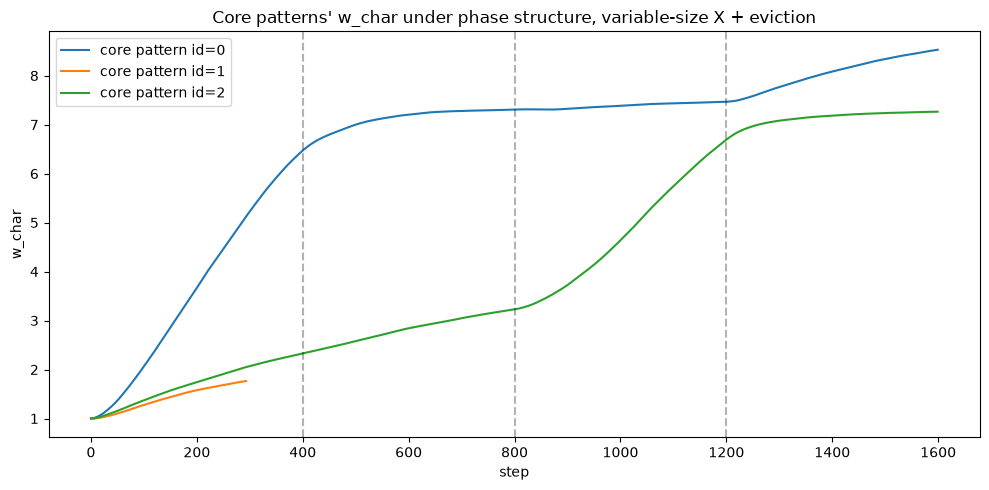

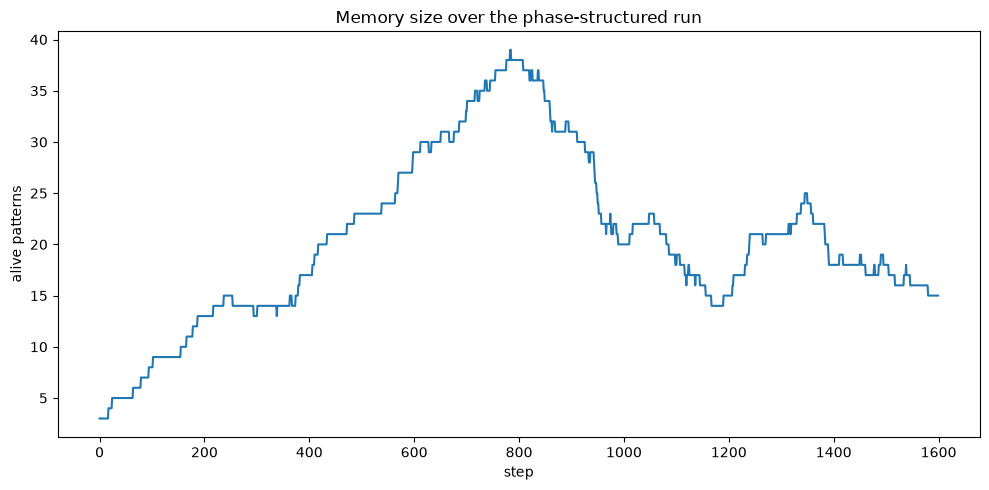

In [5]:
plt.figure(figsize=(10, 5))
for cid in core_ids:
    plt.plot(core_char_history[cid], label=f'core pattern id={cid}')
for pb in phase_bounds[1:-1]:
    plt.axvline(x=pb, color='black', linestyle='--', alpha=0.3)
plt.xlabel("step")
plt.ylabel("w_char")
plt.title("Core patterns' w_char under phase structure, variable-size X + eviction")
plt.legend()
plt.tight_layout()
plt.savefig("check_b_core_char.png", dpi=100)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(alive_count_history)
plt.xlabel("step")
plt.ylabel("alive patterns")
plt.title("Memory size over the phase-structured run")
plt.tight_layout()
plt.savefig("check_b_alive_count.png", dpi=100)
plt.show()

## Final ordering — graded (primacy + recency, no monopolization) like the fixed-X result?

In [6]:
alive_ids = set(mem.ids)
print("Final w_char for core patterns:")
for pos, cid in enumerate(core_ids):
    if cid in alive_ids:
        i = id_to_idx(cid)
        print(f"  core pattern {pos} (id={cid}): w_char={mem.w_char[i]:.3f}, w_fast={mem.w_fast[i]:.3f}")
    else:
        print(f"  core pattern {pos} (id={cid}): EVICTED")

all_char = mem.w_char
sorted_char = sorted(all_char, reverse=True)
if len(sorted_char) > 1:
    ratio = sorted_char[0] / sorted_char[1]
    print(f"\nTop/second w_char ratio (all {len(mem.patterns)} alive patterns): {ratio:.2f} "
          f"(monopolization flagged above 5x)")

print(f"\nFor reference, the original fixed-X sweep's graded order was: "
      f"pattern0 (first+returned) > pattern2 (most recent dominant) > pattern1 > never-dominant patterns")

Final w_char for core patterns:
  core pattern 0 (id=0): w_char=8.527, w_fast=4.619
  core pattern 1 (id=1): EVICTED
  core pattern 2 (id=2): w_char=7.263, w_fast=2.173

Top/second w_char ratio (all 15 alive patterns): 1.17 (monopolization flagged above 5x)

For reference, the original fixed-X sweep's graded order was: pattern0 (first+returned) > pattern2 (most recent dominant) > pattern1 > never-dominant patterns
